In [11]:

!pip install opencv-python matplotlib numpy

In [10]:


import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

from google.colab import files

uploaded = files.upload()

Saving pexels-peter-xie-371876898-37871412.jpg to pexels-peter-xie-371876898-37871412.jpg


In [ ]:
import cv2

img = cv2.imread("image.jpg")

print("Image Loaded Successfully")

Image Loaded Successfully


In [14]:
import cv2

img = cv2.imread("pexels-peter-xie-371876898-37871412.jpg")  # Corrected file name
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [15]:
print("Shape:", img.shape)
print("Height:", img.shape[0])
print("Width:", img.shape[1])
print("Channels:", img.shape[2])
print("Data Type:", img.dtype)

Shape: (4000, 5677, 3)
Height: 4000
Width: 5677
Channels: 3
Data Type: uint8


In [16]:
print(img[100,100])

[2 9 2]


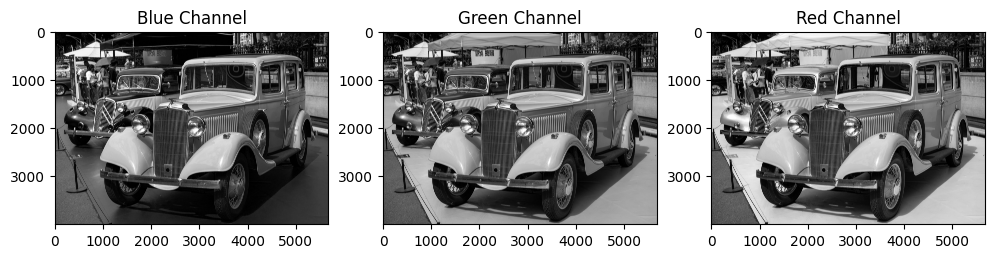

In [17]:
b,g,r = cv2.split(img)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(b,cmap='gray')
plt.title("Blue Channel")

plt.subplot(1,3,2)
plt.imshow(g,cmap='gray')
plt.title("Green Channel")

plt.subplot(1,3,3)
plt.imshow(r,cmap='gray')
plt.title("Red Channel")

plt.show()

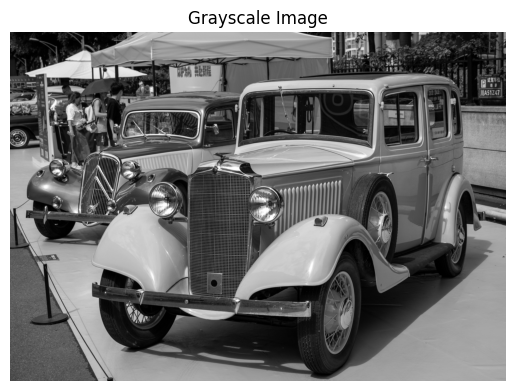

In [18]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray,cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [20]:
from IPython.display import Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

In [21]:
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.body.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [23]:
filename = 'images (1).jpg' # Setting filename to an uploaded image
img = cv2.imread(filename)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [24]:
from google.colab import files

uploaded = files.upload()

Saving 28544-370332703_medium.mp4 to 28544-370332703_medium.mp4


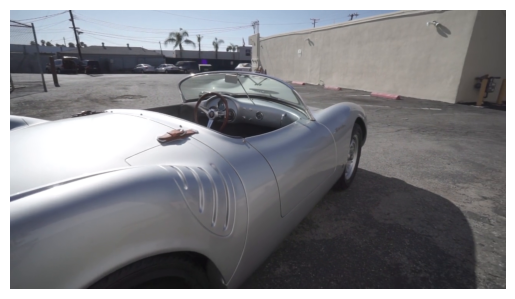

In [ ]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

cap = cv2.VideoCapture("28544-370332703_medium.mp4")

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    clear_output(wait=True)

    plt.imshow(frame)
    plt.axis('off')
    plt.show()

    time.sleep(0.03)  # control playback speed

cap.release()

In [ ]:
import cv2

cap = cv2.VideoCapture("video.mp4")

while True:
    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow("car Video", frame)

    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()